In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving 01 Retail Inventory.xlsx to 01 Retail Inventory.xlsx


In [3]:
import pandas as pd

df = pd.read_excel("01 Retail Inventory.xlsx")
df.head()

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
0,PRD-1001,Wine Glasses,Home & Kitchen,Heritage Brands,23.78,38.89,135,118,17,30,Low Stock
1,PRD-1002,Eye Mask,Beauty,Coastal Trading,15.67,24.53,86,10,76,9,In Stock
2,PRD-1003,Resistance Band,Sports & Outdoors,National Supply Group,5.59,11.88,319,195,124,47,In Stock
3,PRD-1004,Action Figure,Toys & Games,Pacific Wholesale,9.72,18.01,173,140,33,39,Low Stock
4,PRD-1005,Serving Tray,Home & Kitchen,Coastal Trading,8.22,13.90,32,8,24,7,In Stock


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product ID     1000 non-null   object 
 1   Product Name   1000 non-null   object 
 2   Category       1000 non-null   object 
 3   Supplier Name  1000 non-null   object 
 4   Unit Cost      1000 non-null   float64
 5   Retail Price   1000 non-null   float64
 6   Opening Stock  1000 non-null   int64  
 7   Units Sold     1000 non-null   int64  
 8   Closing Stock  1000 non-null   int64  
 9   Reorder Point  1000 non-null   int64  
 10  Stock Status   1000 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 86.1+ KB


## Training a Simple Machine Learning Model

We will train a simple Linear Regression model to predict the `Retail Price` based on numerical features like `Unit Cost`, `Opening Stock`, `Units Sold`, `Closing Stock`, and `Reorder Point`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Define features (X) and target (y)
features = ['Unit Cost', 'Opening Stock', 'Units Sold', 'Closing Stock', 'Reorder Point']
X = df[features]
y = df['Retail Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

### Model Training

Now, let's train a Linear Regression model using our training data.

In [ ]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")

### Model Evaluation

Let's evaluate the model's performance on the test set using Mean Absolute Error (MAE) and R-squared (R2) score.

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

# Optionally, visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Retail Price")
plt.ylabel("Predicted Retail Price")
plt.title("Actual vs. Predicted Retail Price")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Perfect prediction line
plt.show()

In [5]:
df.isnull().sum()

,0
Product ID,0
Product Name,0
Category,0
Supplier Name,0
Unit Cost,0
Retail Price,0
Opening Stock,0
Units Sold,0
Closing Stock,0
Reorder Point,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Category'].value_counts()

,count
Category,
Beauty,134
Sports & Outdoors,132
Electronics,126
Office Supplies,126
Home & Kitchen,124
Toys & Games,123
Grocery,119
Clothing,116


In [8]:
df.groupby('Category')['Units Sold'].sum()

,Units Sold
Category,
Beauty,18137
Clothing,13736
Electronics,17621
Grocery,15364
Home & Kitchen,18387
Office Supplies,17112
Sports & Outdoors,16979
Toys & Games,19704


In [9]:
df.sort_values(by='Units Sold', ascending=False).head(10)

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
721,PRD-1722,Water Bottle,Sports & Outdoors,Summit Wholesale Inc,1.38,2.68,489,463,26,95,Low Stock
476,PRD-1477,Canned Soup,Grocery,Global Source Direct,8.12,15.92,490,456,34,56,Low Stock
791,PRD-1792,Coffee Mug Set,Home & Kitchen,Coastal Trading,12.36,17.50,471,435,36,93,Low Stock
673,PRD-1674,LED Desk Lamp,Electronics,Metro Distributors,65.20,131.63,497,432,65,76,Low Stock
810,PRD-1811,Coloring Set,Toys & Games,Pacific Wholesale,17.03,31.50,457,428,29,55,Low Stock
243,PRD-1244,Notebook A5,Office Supplies,AllGoods Supply Co,2.65,5.11,464,423,41,58,Low Stock
970,PRD-1971,Baseball Cap,Clothing,AllGoods Supply Co,11.13,24.20,475,422,53,87,Low Stock
550,PRD-1551,Whistle,Sports & Outdoors,Premier Merchandise,11.41,15.84,478,422,56,62,Low Stock
931,PRD-1932,Rice Crackers,Grocery,AllGoods Supply Co,10.45,14.70,448,417,31,102,Low Stock
469,PRD-1470,Building Blocks,Toys & Games,Heritage Brands,19.26,36.10,494,416,78,99,Low Stock


In [10]:
df.sort_values(by='Closing Stock').head(10)

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
45,PRD-1046,Basic T-Shirt,Clothing,United Imports,24.64,41.77,42,38,4,5,Low Stock
385,PRD-1386,Coloring Set,Toys & Games,Premier Merchandise,7.70,11.57,61,57,4,14,Low Stock
819,PRD-1820,Notebook A5,Office Supplies,Coastal Trading,7.80,13.91,25,21,4,2,In Stock
654,PRD-1655,Storage Container,Home & Kitchen,National Supply Group,23.10,35.70,41,37,4,4,Low Stock
425,PRD-1426,Nail File Set,Beauty,AllGoods Supply Co,16.02,32.05,88,83,5,11,Low Stock
391,PRD-1392,Eye Mask,Beauty,Pacific Wholesale,11.30,17.07,76,71,5,7,Low Stock
703,PRD-1704,Coffee Mug Set,Home & Kitchen,AllGoods Supply Co,26.38,49.78,33,28,5,8,Low Stock
977,PRD-1978,Cotton Pads,Beauty,National Supply Group,7.70,14.41,37,31,6,4,In Stock
698,PRD-1699,Whistle,Sports & Outdoors,Global Source Direct,8.74,18.95,21,15,6,3,In Stock
709,PRD-1710,Dry Shampoo,Beauty,Summit Wholesale Inc,8.93,16.55,35,29,6,3,In Stock


In [11]:
df.sort_values(by='Closing Stock').head(10)


,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
45,PRD-1046,Basic T-Shirt,Clothing,United Imports,24.64,41.77,42,38,4,5,Low Stock
385,PRD-1386,Coloring Set,Toys & Games,Premier Merchandise,7.70,11.57,61,57,4,14,Low Stock
819,PRD-1820,Notebook A5,Office Supplies,Coastal Trading,7.80,13.91,25,21,4,2,In Stock
654,PRD-1655,Storage Container,Home & Kitchen,National Supply Group,23.10,35.70,41,37,4,4,Low Stock
425,PRD-1426,Nail File Set,Beauty,AllGoods Supply Co,16.02,32.05,88,83,5,11,Low Stock
391,PRD-1392,Eye Mask,Beauty,Pacific Wholesale,11.30,17.07,76,71,5,7,Low Stock
703,PRD-1704,Coffee Mug Set,Home & Kitchen,AllGoods Supply Co,26.38,49.78,33,28,5,8,Low Stock
977,PRD-1978,Cotton Pads,Beauty,National Supply Group,7.70,14.41,37,31,6,4,In Stock
698,PRD-1699,Whistle,Sports & Outdoors,Global Source Direct,8.74,18.95,21,15,6,3,In Stock
709,PRD-1710,Dry Shampoo,Beauty,Summit Wholesale Inc,8.93,16.55,35,29,6,3,In Stock


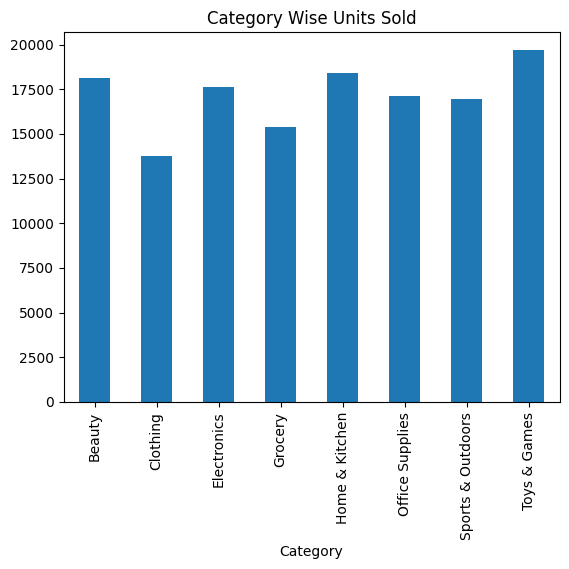

In [12]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['Units Sold'].sum()

category_sales.plot(kind='bar')

plt.title("Category Wise Units Sold")
plt.show()

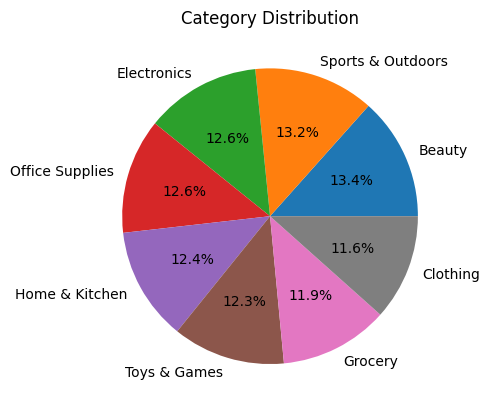

In [13]:
df['Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Category Distribution")
plt.ylabel("")
plt.show()

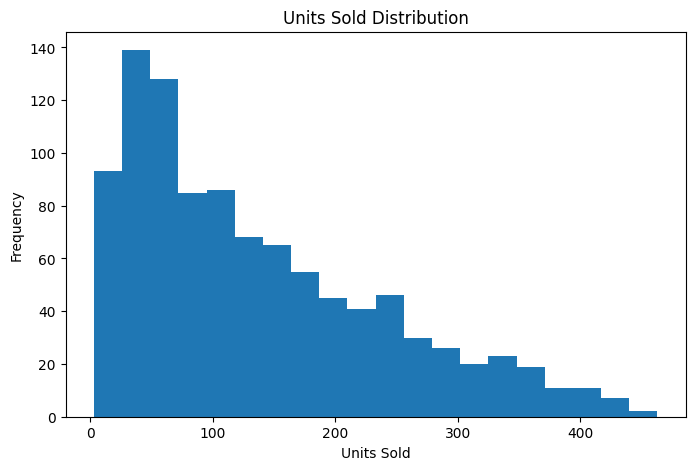

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df['Units Sold'], bins=20)

plt.title("Units Sold Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.show()

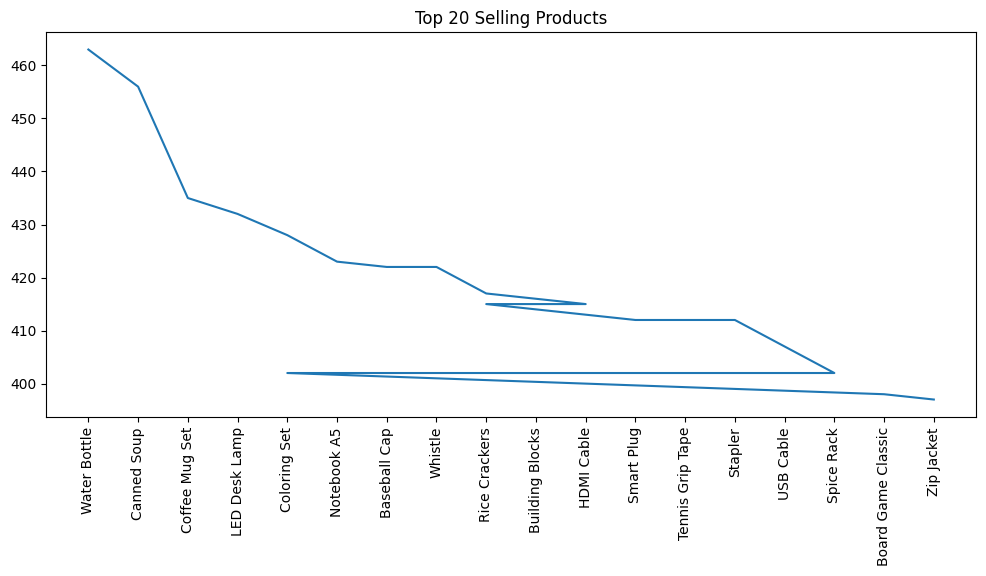

In [15]:
top20 = df.sort_values(
    by='Units Sold',
    ascending=False
).head(20)

plt.figure(figsize=(12,5))

plt.plot(top20['Product Name'],
         top20['Units Sold'])

plt.xticks(rotation=90)

plt.title("Top 20 Selling Products")

plt.show()

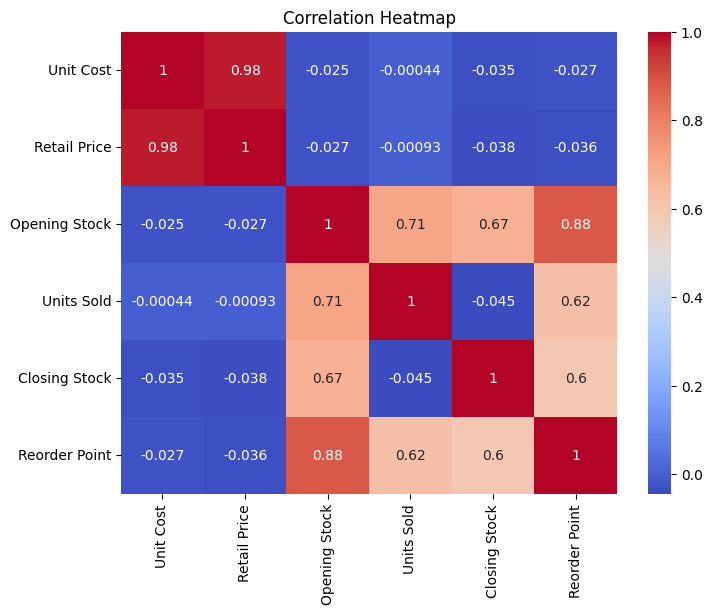

In [16]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
top_products = df[['Product Name','Units Sold']].sort_values(
    by='Units Sold',
    ascending=False
).head(10)

top_products

,Product Name,Units Sold
721,Water Bottle,463
476,Canned Soup,456
791,Coffee Mug Set,435
673,LED Desk Lamp,432
810,Coloring Set,428
243,Notebook A5,423
970,Baseball Cap,422
550,Whistle,422
931,Rice Crackers,417
469,Building Blocks,416


In [18]:
top_products = df[['Product Name','Units Sold']].sort_values(
    by='Units Sold',
    ascending=False
).head(10)

top_products

,Product Name,Units Sold
721,Water Bottle,463
476,Canned Soup,456
791,Coffee Mug Set,435
673,LED Desk Lamp,432
810,Coloring Set,428
243,Notebook A5,423
970,Baseball Cap,422
550,Whistle,422
931,Rice Crackers,417
469,Building Blocks,416


In [19]:
low_stock = df[['Product Name','Closing Stock']].sort_values(
    by='Closing Stock'
).head(10)

low_stock

,Product Name,Closing Stock
45,Basic T-Shirt,4
385,Coloring Set,4
819,Notebook A5,4
654,Storage Container,4
425,Nail File Set,5
391,Eye Mask,5
703,Coffee Mug Set,5
977,Cotton Pads,6
698,Whistle,6
709,Dry Shampoo,6


In [20]:
supplier_inventory = df['Supplier Name'].value_counts()

supplier_inventory

,count
Supplier Name,
Premier Merchandise,119
National Supply Group,116
Heritage Brands,109
Coastal Trading,103
Global Source Direct,103
United Imports,99
Pacific Wholesale,98
Summit Wholesale Inc,92
Metro Distributors,89


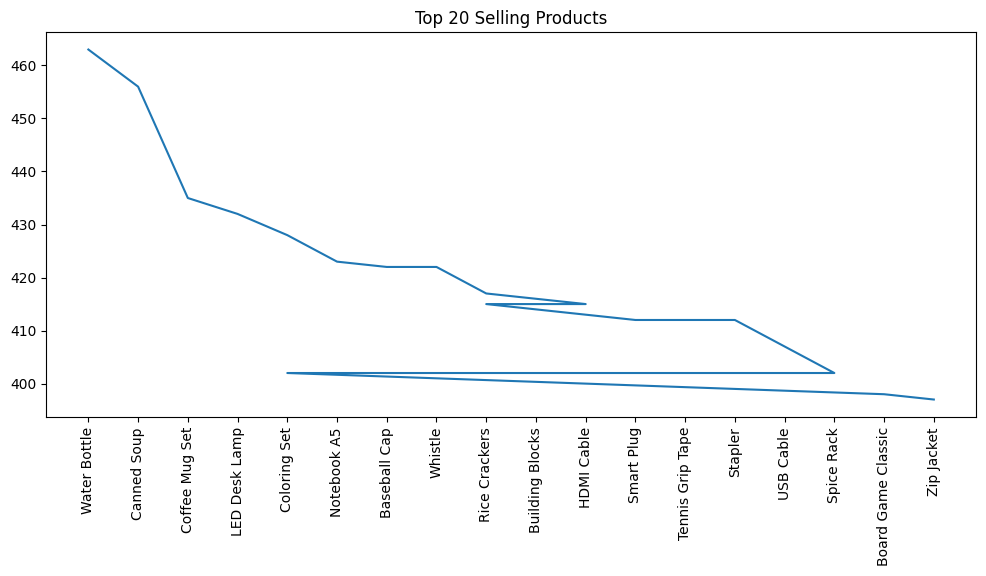

In [21]:
top20 = df.sort_values(
    by='Units Sold',
    ascending=False
).head(20)

plt.figure(figsize=(12,5))

plt.plot(top20['Product Name'],
         top20['Units Sold'])

plt.xticks(rotation=90)

plt.title("Top 20 Selling Products")

plt.show()

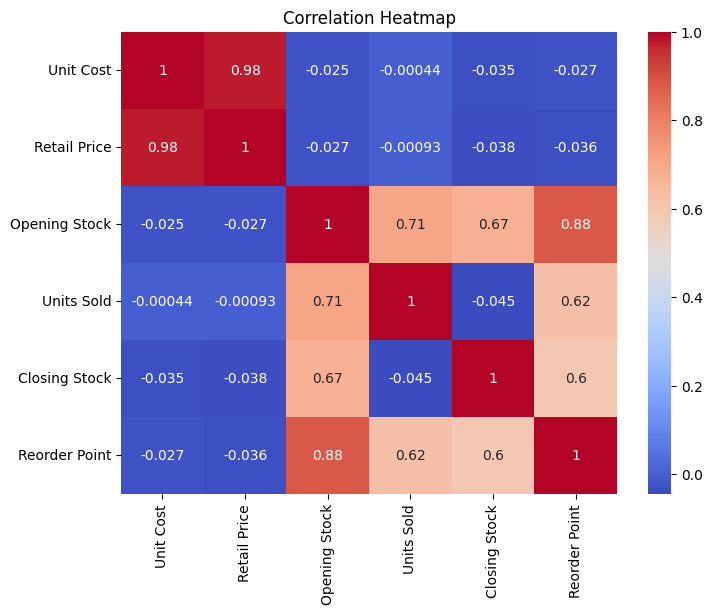

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()